# How to track work (terminal)
only once: git init

every time:
git add .
git commit -m "insert message"

In [29]:
import numpy as np
import numpy.ma as ma
from numpy import shape
import matplotlib.pyplot as plt
import netCDF4 as nc
# from scipy.io import loadmat
#from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import datetime
import copernicusmarine as cm

In [ ]:
# # dowloading the CMEMS data
# # dates I want: 01/01/1994 - 12/31/2024
# # let's try 100W to 20E and 0 to 80N for horizontal extent

# # Note: ERA5 reanalysis SST data is available from 1940-present
# cm.subset(
#   dataset_id="c3s_obs-sl_glo_phy-ssh_my_twosat-l4-duacs-0.25deg_P1D",
#   variables=["eke"],
#   minimum_longitude=15,
#   maximum_longitude=150,
#   minimum_latitude=-50,
#   maximum_latitude=-30,
#   start_datetime="1994-01-01",
#   end_datetime="2024-12-31",
#   output_filename = "ARC_EKE.nc",
# )

INFO - 2026-04-13T20:39:00Z - Selected dataset version: "202411"
INFO - 2026-04-13T20:39:00Z - Selected dataset part: "default"
100%|██████████| 47/47 [00:06<00:00,  6.73it/s]


ResponseSubset(file_path=PosixPath('ARC_EKE.nc'), output_directory=PosixPath('.'), filename='ARC_EKE.nc', file_size=61.35040458015267, data_transfer_size=249.88726717557253, variables=['eke'], coordinates_extent=[GeographicalExtent(minimum=15.125, maximum=149.875, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=-49.875, maximum=-30.125, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='1994-01-01T00:00:00+00:00', maximum='2024-12-01T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [21]:
# Load data
data_in = 'ARC_EKE.nc'
f = nc.Dataset((data_in))
eke_ = f.variables['eke'][:] # eddy kinetic energy (time, lat, lon)
time = f.variables['time'][:] # time
lat = f.variables['latitude'][:] # latitude
lon = f.variables['longitude'][:] # longitude

In [22]:
eke = np.swapaxes(eke_,1,2)

In [23]:
print(np.shape(eke)) # (time, longitude, latitude)
print(type(eke))
print(f['eke'].units)

(372, 540, 80)
<class 'numpy.ma.MaskedArray'>
cm2/s2


In [24]:
print(eke[0])

[[108.4572 101.533 62.9902 ... 23.5959 23.639400000000002 25.1994]
 [151.9224 112.33250000000001 68.8801 ... 17.9464 13.776800000000001
  17.3061]
 [161.36960000000002 129.7412 86.5467 ... 14.058300000000001 10.9144
  14.6081]
 ...
 [33.6839 124.65830000000001 181.6739 ... -- -- --]
 [63.3939 19.0069 86.4546 ... -- -- --]
 [145.1506 81.6213 18.662000000000003 ... -- -- --]]


In [25]:
print(f['time'].units)
print(f['time'].shape)

days since 1950-01-01
(372,)


In [30]:
from datetime import timedelta

# CNES epoch: January 1, 1950
CNES_EPOCH = datetime.datetime(1950,1,1,0,0,0)

datetime_list = []
for t in time:
    # Convert CNES days (days since 1950-01-01) to a datetime object
    dt_object = CNES_EPOCH + timedelta(days=float(t))
    str_formatted_time = dt_object.strftime('%Y-%m-%d %H:%M:%S')
    formatted_time = np.datetime64(str_formatted_time)
    datetime_list.append(formatted_time)

datetime_array = ma.masked_array(datetime_list, mask=np.isnan(time))
print(shape(datetime_array)) #checks out with shape of original time variable
print(datetime_array[0]) # prints the first datetime value
print(type(datetime_array[0])) # checks the type of the first datetime value

# LET'S GO0000. WE FINALLY MADE IT WORK. 

(372,)
1994-01-01T00:00:00
<class 'numpy.datetime64'>


In [31]:
# some housekeeping

# Display date range
print(f"Start date: {datetime_array[0]}")
print(f"End date: {datetime_array[-1]}")

# Get dimensions
nlat = len(lat)
nlon = len(lon)
print("Dimensions: ", nlat, " lat,", nlon, " lon")

# Extract years from datetime values and count unique years
years_list = [d.astype('datetime64[Y]').astype(int) +1970 for d in datetime_array]
years = np.unique(years_list)
print(f"Number of years: {len(years)}") # number of unique years in the data set
print("Years list shape: ", shape(years_list)) # number of dates in the data set
print(years_list)

Start date: 1994-01-01T00:00:00
End date: 2024-12-01T00:00:00
Dimensions:  80  lat, 540  lon
Number of years: 31
Years list shape:  (372,)
[np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1994), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1995), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1996), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1997), np.int64(1998), np.int64(1998), np.int64(1998), np.int64(1998), np.int64(1998), np.int64(199

In [49]:
# Initialize arrays for eke
ekeMonthMean = np.zeros((nlon, nlat, len(years), 12)) # shape: (time, lat, lon, 12)
scaled_ekeMonthMean = np.zeros((nlon, nlat, len(years), 12)) 
#ekeYearMean = np.zeros((nlon, nlat, len(years))) # shape: (time, lat, lon)

# Calculate monthly and yearly means
for i, year_val in enumerate(years):
    # Get indices for current year
    isyear = np.array([d.astype('datetime64[Y]').astype(int) + 1970 == year_val for d in datetime_array])
    # ^ looping over the data values and checking if the year of each datetime value matches the current year in the loop

    # # Calculate yearly mean
    # ekeYearMean[:, :, i] = np.mean(eke[isyear, :, :], axis=0)
    
    # Calculate monthly means
    for j in range(12): 
        ismonth = np.array([d.astype('datetime64[M]').astype(int) % 12 + 1 == (j + 1) for d in datetime_array])
        ekeMonthMean[:, :, i, j] = np.mean(eke[ismonth & isyear, :, :], axis=0)
        scaled_ekeMonthMean[:,:,i,j] = np.multiply(ekeMonthMean[:,:,i,j], 0.01) # scale eke values for better visualization

In [50]:
print(ekeMonthMean.min(), ekeMonthMean.max())
print(scaled_ekeMonthMean.min(), scaled_ekeMonthMean.max())

0.0 20319.4705
0.0 203.194705


In [70]:
# Calculate the overall mean across all years and months for each grid point
overall_mean_eke = np.mean(ekeMonthMean, axis=(2, 3)) # averaging over years and months
overall_mean_scaled_eke = np.multiply(overall_mean_eke, 0.01)

In [77]:
print(overall_mean_scaled_eke.shape)
print(overall_mean_scaled_eke.min(), overall_mean_scaled_eke.max())

(540, 80)
0.0 32.58635835215054


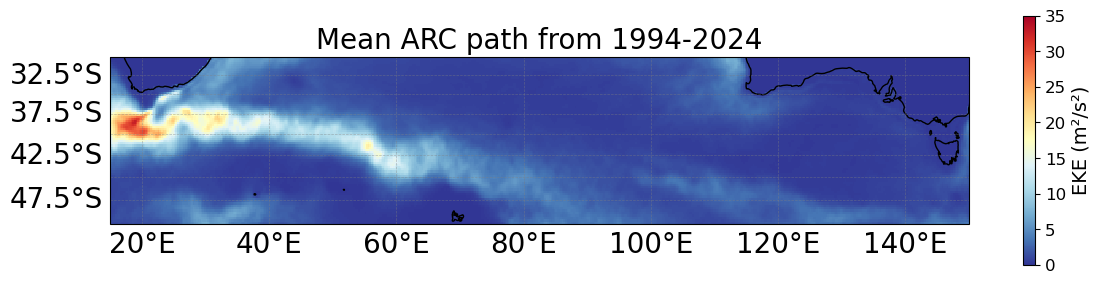

In [78]:
fig = plt.figure(k, figsize=(13.85, 4.05))
ax = plt.axes(projection=ccrs.Mercator())
        
# Set map extent
ax.set_extent([15, 150, -50, -30], crs=ccrs.PlateCarree())
            
pcm = ax.pcolormesh(lon, lat, overall_mean_scaled_eke.T,
    cmap='RdYlBu_r',
    vmin=0, vmax=35,
    transform=ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
cbar.set_label('EKE (m²/s²)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

            
# Add coastlines
ax.add_feature(cfeature.LAND, facecolor=[0.7, 0.7, 0.7], edgecolor='black')
ax.coastlines()
            
# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, 
    color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 20}
gl.ylabel_style = {'size': 20}
            
# Set title
plt.title(f'Mean ARC path from 1994-2024', fontsize=20)
            
# Save figure
# filename = output_dir / f'ADT_EKE_{years[k]:04d}_{j+1:02d}.png'
# plt.savefig(filename, dpi=100, bbox_inches='tight')
plt.show()

In [57]:
# Create output directory
output_dir = Path('./ARC_EKE Figures')
output_dir.mkdir(parents=True, exist_ok=True)

In [61]:
# # Create plots for each year
# for k in range(len(years)): 
#     # Plot monthly mean EKE as a colormap
#     for j in range(12):
#         fig = plt.figure(k, figsize=(13.85, 4.05))
#         ax = plt.axes(projection=ccrs.Mercator())
    
#         # Set map extent
#         ax.set_extent([15, 150, -50, -30], crs=ccrs.PlateCarree())
        
#         pcm = ax.pcolormesh(lon, lat, scaled_ekeMonthMean[:, :, k, j].T,
#                             cmap='RdYlBu_r',
#                             vmin=0, vmax=100,
#                             transform=ccrs.PlateCarree())

#         # Add colorbar
#         cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
#         cbar.set_label('EKE (m²/s²)', fontsize=14)
#         cbar.ax.tick_params(labelsize=12)

        
#         # Add coastlines
#         ax.add_feature(cfeature.LAND, facecolor=[0.7, 0.7, 0.7], edgecolor='black')
#         ax.coastlines()
        
#         # Add gridlines
#         gl = ax.gridlines(draw_labels=True, linewidth=0.5, 
#                         color='gray', alpha=0.5, linestyle='--')
#         gl.top_labels = False
#         gl.right_labels = False
#         gl.xlabel_style = {'size': 20}
#         gl.ylabel_style = {'size': 20}
        
#         # Set title
#         plt.title(f'ARC path in {years[k]}/{j+1}', fontsize=20)
        
#         # Save figure
#         filename = output_dir / f'ADT_EKE_{years[k]:04d}_{j+1:02d}.png'
#         plt.savefig(filename, dpi=100, bbox_inches='tight')
#         plt.show()

In [ ]:
import imageio.v3 as iio
# Create animated GIF
filenames = sorted(output_dir.glob('ARC_EKE_*.png'))
images = [ ]

for filename in filenames:
  images.append(iio.imread(filename))

iio.imwrite('ARC_EKE.gif', images, duration = 200, loop = 0)